# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


**Dataset Cuaca Per Jam Indonesia untuk Prediksi Hujan**

Dataset ini berisi pengamatan cuaca historis per jam dari berbagai kota di Indonesia, yang dikumpulkan melalui API publik Open-Meteo, dan disiapkan untuk penelitian pembelajaran mesin dan pembelajaran mendalam, khususnya untuk tugas prediksi curah hujan jangka pendek.

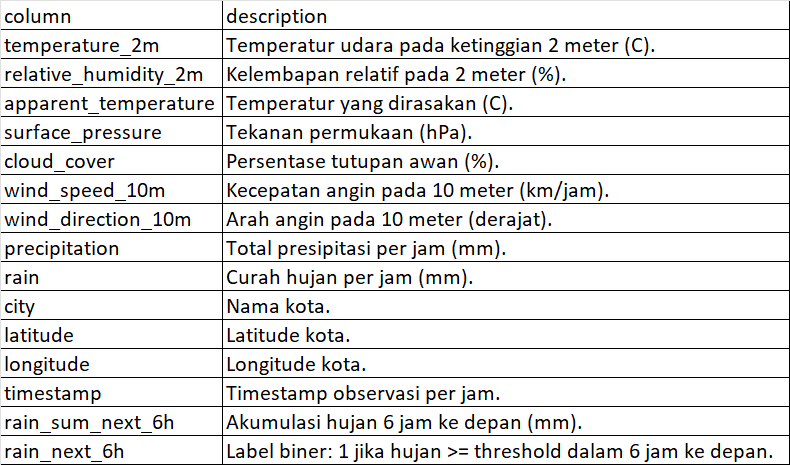

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
#Type your code here
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats

from sklearn.preprocessing import StandardScaler, LabelEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
data = pd.read_csv('/content/weather_raw.csv')
data.head(5)

,temperature_2m,relative_humidity_2m,apparent_temperature,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,precipitation,rain,city,latitude,longitude,timestamp,rain_sum_next_6h,rain_next_6h
0,19.8,82,20.9,932.4,100,7.4,331,0.0,0.0,Bandung,-6.9175,107.6191,2022-01-01 05:00:00,0.1,1
1,18.9,89,20.4,932.8,100,6.4,322,0.0,0.0,Bandung,-6.9175,107.6191,2022-01-01 06:00:00,0.0,0
2,21.6,78,23.9,933.8,100,3.6,323,0.0,0.0,Bandung,-6.9175,107.6191,2022-01-01 07:00:00,0.0,0
3,22.7,78,25.1,934.6,100,5.9,322,0.0,0.0,Bandung,-6.9175,107.6191,2022-01-01 08:00:00,0.0,0
4,23.7,74,26.1,935.1,100,6.4,317,0.0,0.0,Bandung,-6.9175,107.6191,2022-01-01 09:00:00,0.0,0


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

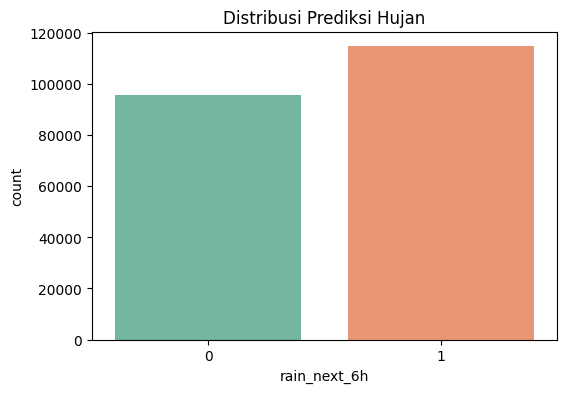

In [4]:
#Type your code here
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='rain_next_6h', hue='rain_next_6h', palette='Set2', legend=False)
plt.title('Distribusi Prediksi Hujan')
plt.show()

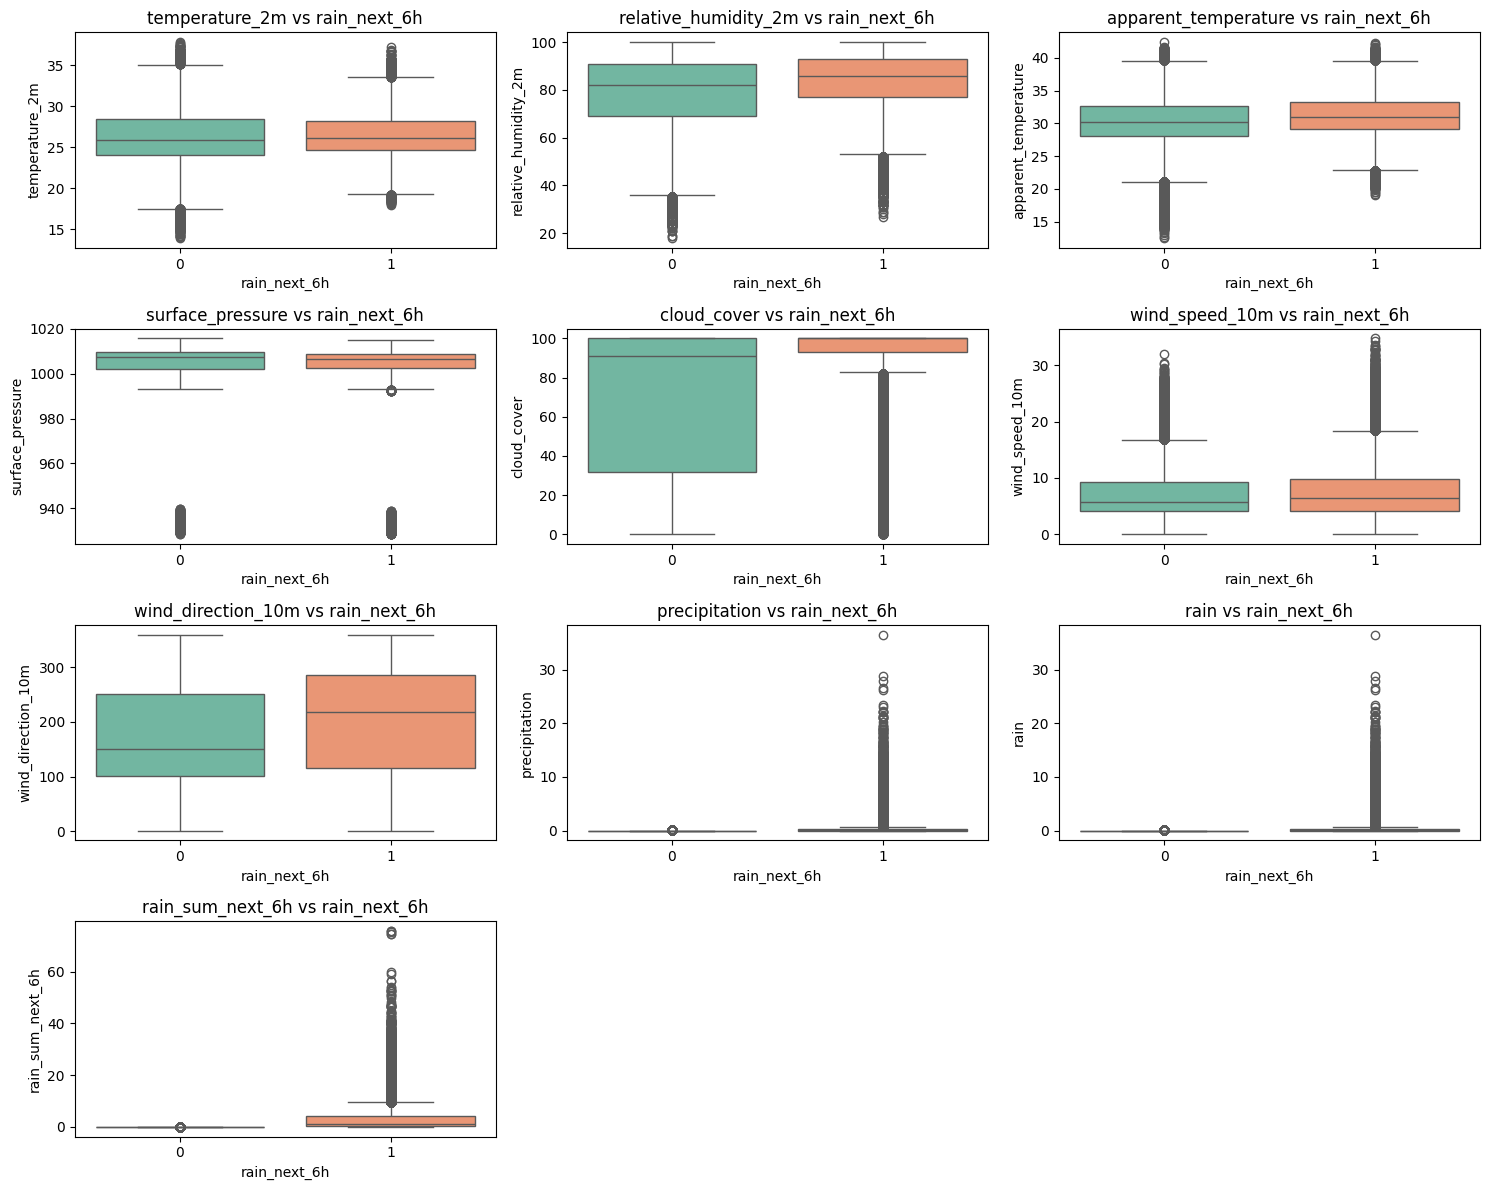

In [5]:
features = ['temperature_2m', 'relative_humidity_2m', 'apparent_temperature', 'surface_pressure', 'cloud_cover', 'wind_speed_10m', 'wind_direction_10m', 'precipitation', 'rain', 'rain_sum_next_6h']

plt.figure(figsize=(15, 12))
for i, feature in enumerate(features, 1):
    plt.subplot(4, 3, i)
    sns.boxplot(data=data, x='rain_next_6h', y=feature, hue='rain_next_6h', palette='Set2', legend=False)
    plt.title(f'{feature} vs rain_next_6h')

plt.tight_layout()
plt.show()

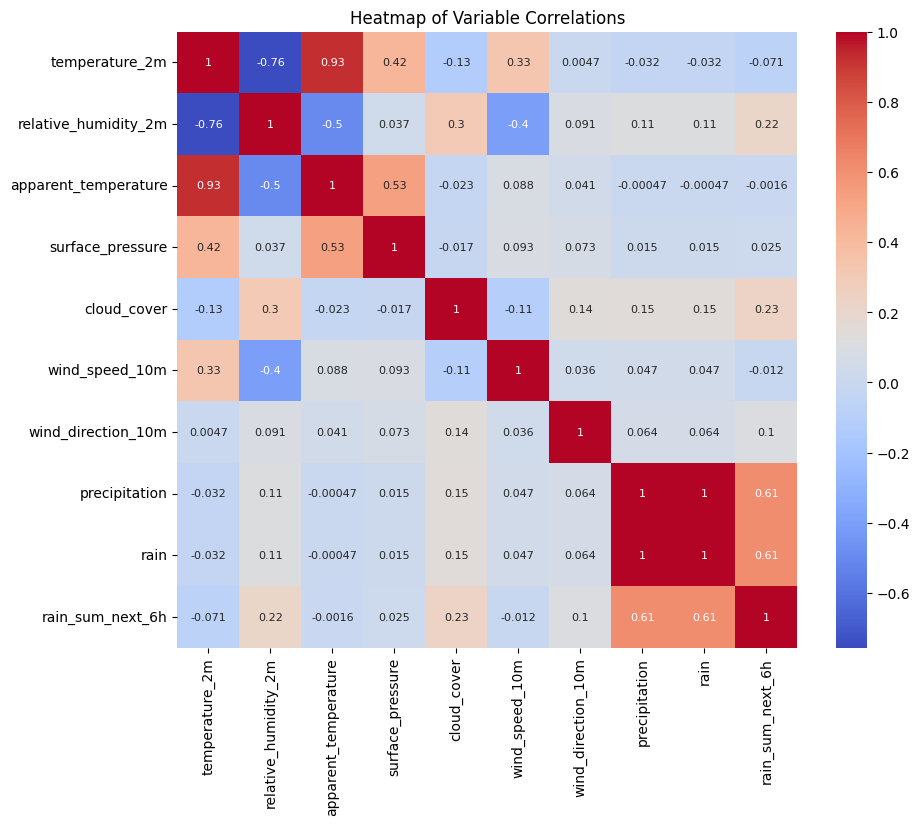

In [6]:
correlation_matrix = data[features].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', annot_kws={'size':8})
plt.title('Heatmap of Variable Correlations')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [7]:
print("Duplikasi:", data.duplicated().sum())
print("Missing values:\n", data.isna().sum())

data = data.dropna().reset_index(drop=True)

Duplikasi: 0
Missing values:
 temperature_2m          0
relative_humidity_2m    0
apparent_temperature    0
surface_pressure        0
cloud_cover             0
wind_speed_10m          0
wind_direction_10m      0
precipitation           0
rain                    0
city                    0
latitude                0
longitude               0
timestamp               0
rain_sum_next_6h        0
rain_next_6h            0
dtype: int64


In [8]:
z_scores = np.abs(stats.zscore(data.select_dtypes(include=[np.number])))
outliers = (z_scores > 3).any(axis=1)
print(f"Jumlah outlier yang dihapus: {outliers.sum()}")
data = data[~outliers].reset_index(drop=True)

Jumlah outlier yang dihapus: 13578


In [9]:
# Encoding
label_encoder = LabelEncoder()
data['rain_next_6h'] = label_encoder.fit_transform(data['rain_next_6h'])

In [10]:
X = data[features]
y = data['rain_next_6h']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

processed_data = pd.DataFrame(X_scaled, columns=X.columns)
processed_data['rain_next_6h'] = y.values

processed_data.head()

,temperature_2m,relative_humidity_2m,apparent_temperature,surface_pressure,cloud_cover,wind_speed_10m,wind_direction_10m,precipitation,rain,rain_sum_next_6h,rain_next_6h
0,-2.227472,0.032909,-2.749927,-2.715176,0.652815,0.059783,1.459516,-0.351369,-0.351369,-0.479643,1
1,-2.538648,0.576543,-2.889740,-2.698599,0.652815,-0.178555,1.367718,-0.351369,-0.351369,-0.522629,0
2,-1.605119,-0.277740,-1.911048,-2.657155,0.652815,-0.845899,1.377918,-0.351369,-0.351369,-0.522629,0
3,-1.224792,-0.277740,-1.575496,-2.623999,0.652815,-0.297723,1.367718,-0.351369,-0.351369,-0.522629,0
4,-0.879041,-0.588388,-1.295870,-2.603277,0.652815,-0.178555,1.316719,-0.351369,-0.351369,-0.522629,0


In [12]:
processed_data.to_csv('weather_preprocessing.csv', index=False)